In [1]:
import warnings
warnings.filterwarnings('ignore')

import pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

OUTPUT_DIR = '../output'
plt.rcParams['figure.figsize'] = (13, 5)
sns.set_theme(style='whitegrid', font_scale=1.05)

# ── Load data dari Tahap 2 ───────────────────────────────────
with open(f'{OUTPUT_DIR}/tahap2_pca.pkl', 'rb') as f:
    d = pickle.load(f)

representasi = d['representasi']
meta_linear  = d['meta_linear']
meta_poly    = d['meta_poly']
X_linear     = d['X_linear']
X_poly       = d['X_poly']

print('Data berhasil dimuat.')
print(f'Total representasi : {len(representasi)}')
print('\nRepresentasi yang tersedia:')
for nama, X in representasi.items():
    print(f'  {nama:<15} → shape: {X.shape}')

Data berhasil dimuat.
Total representasi : 8

Representasi yang tersedia:
  Linear-204      → shape: (37, 204)
  Linear-203      → shape: (37, 203)
  Linear-74       → shape: (37, 74)
  Linear-37       → shape: (37, 37)
  Poly-204        → shape: (37, 204)
  Poly-203        → shape: (37, 203)
  Poly-74         → shape: (37, 74)
  Poly-37         → shape: (37, 37)


In [2]:
# ── Parameter eksperimen ─────────────────────────────────────
K_RANGE      = range(2, 11)   # k dari 2 sampai 10
N_INIT       = 20             # Lebih banyak inisialisasi → lebih stabil
RANDOM_STATE = 42

hasil = []        # Kumpulkan semua hasil
labels_map = {}   # Simpan label untuk setiap (dataset, k)

total = len(representasi) * len(K_RANGE)
run   = 0

print(f'Menjalankan {total} eksperimen...')
print('=' * 65)

for nama_data, X in representasi.items():
    best_sil, best_k = -1, 2
    for k in K_RANGE:
        run += 1
        km     = KMeans(n_clusters=k, n_init=N_INIT,
                        init='k-means++', random_state=RANDOM_STATE)
        labels = km.fit_predict(X)
        sil    = silhouette_score(X, labels)
        iner   = km.inertia_

        labels_map[(nama_data, k)] = labels
        hasil.append({
            'dataset'   : nama_data,
            'k'         : k,
            'silhouette': round(sil, 6),
            'inertia'   : round(iner, 4),
        })
        if sil > best_sil:
            best_sil, best_k = sil, k

    print(f'  {nama_data:<15}  k_terbaik = {best_k}   silhouette = {best_sil:.4f}')

df_hasil = pd.DataFrame(hasil)
print(f'\nSelesai! Total {run} eksperimen dijalankan.')

Menjalankan 72 eksperimen...


  Linear-204       k_terbaik = 2   silhouette = 0.4909


  Linear-203       k_terbaik = 2   silhouette = 0.4909


  Linear-74        k_terbaik = 2   silhouette = 0.4021


  Linear-37        k_terbaik = 2   silhouette = 0.4021


  Poly-204         k_terbaik = 2   silhouette = 0.5375


  Poly-203         k_terbaik = 2   silhouette = 0.5375


  Poly-74          k_terbaik = 3   silhouette = 0.4543


  Poly-37          k_terbaik = 3   silhouette = 0.4543

Selesai! Total 72 eksperimen dijalankan.


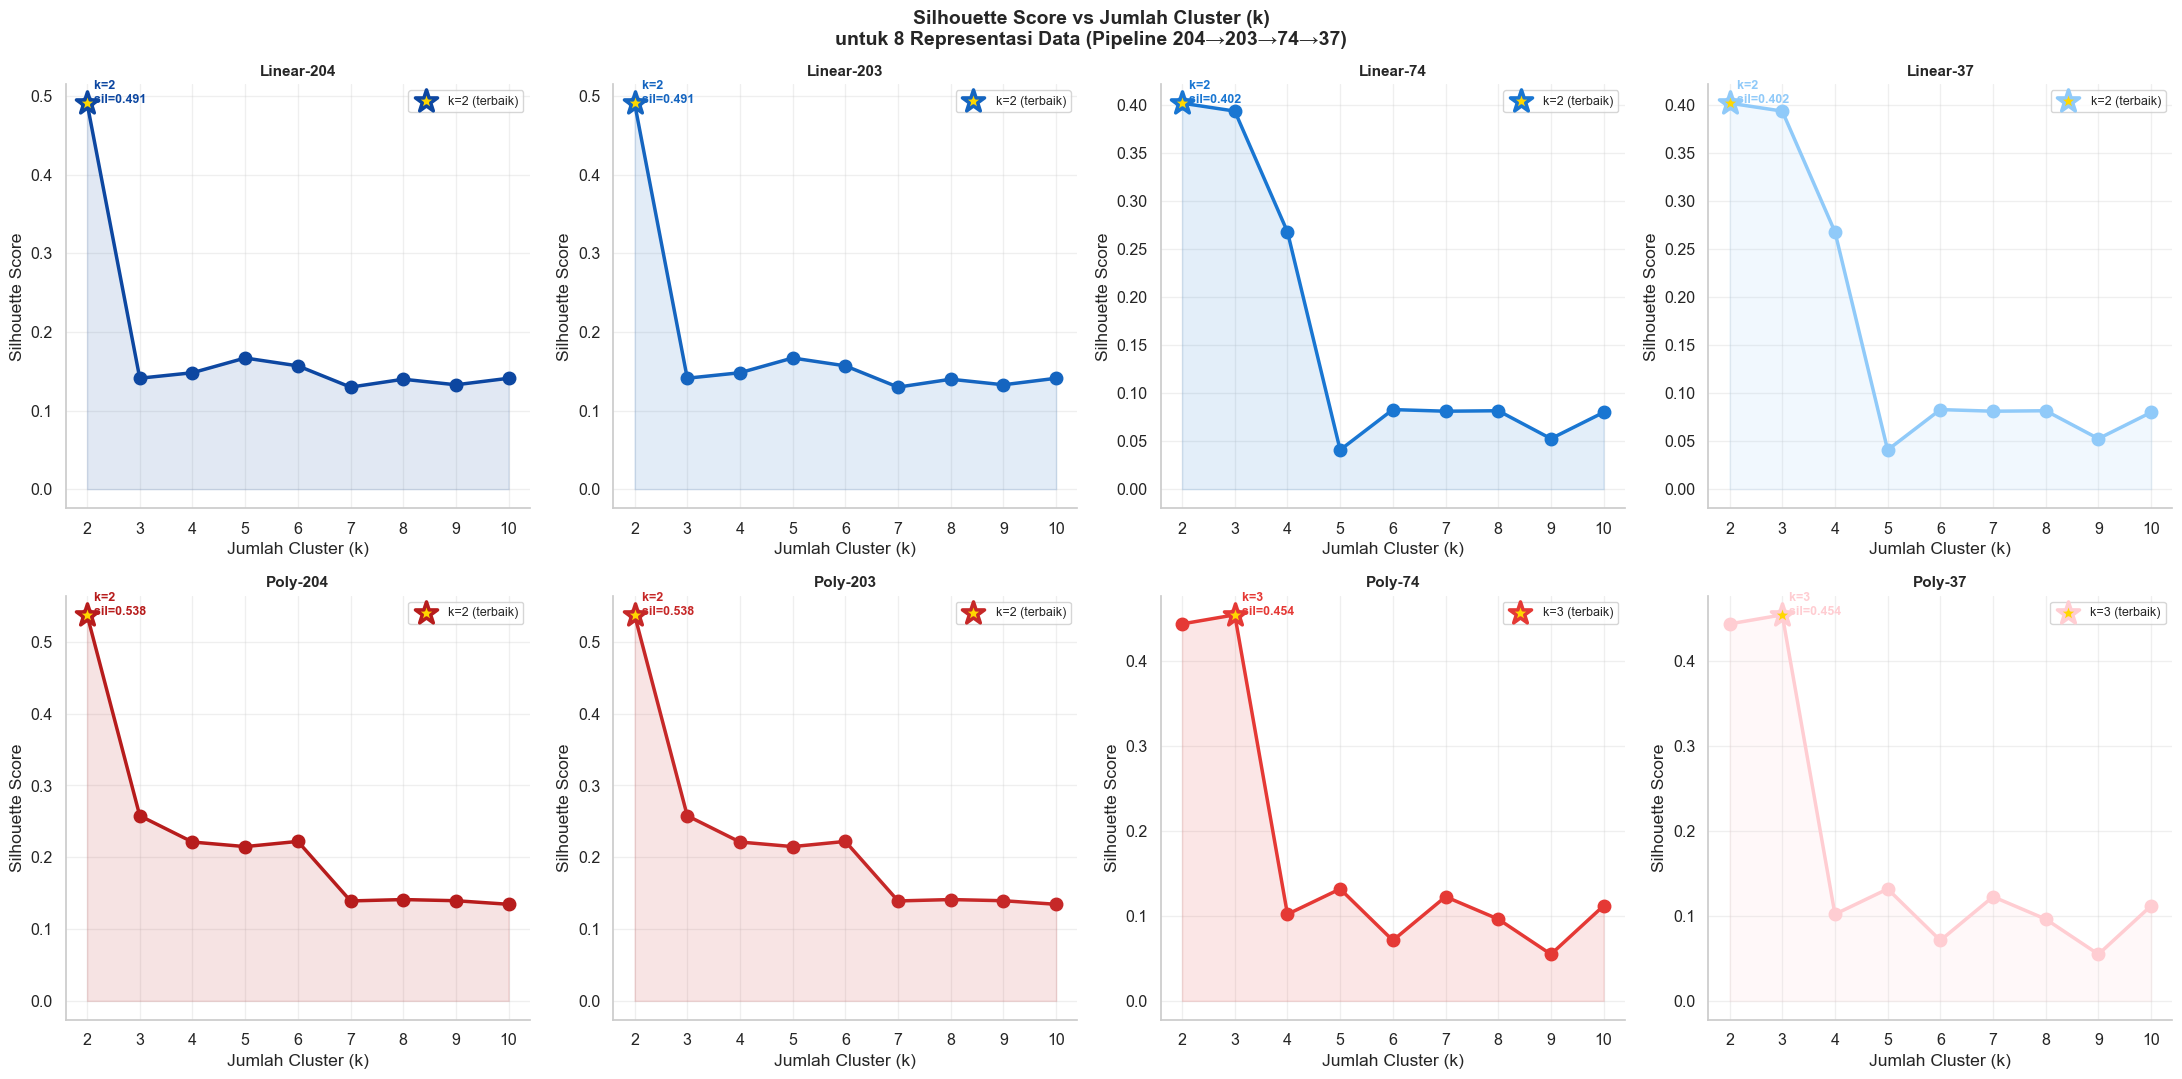

Gambar disimpan: output/07_silhouette_semua.png


In [3]:
# ── Warna per dataset ─────────────────────────────────────────
PALETTE = {
    'Linear-204': '#0D47A1', 'Linear-203': '#1565C0',
    'Linear-74' : '#1976D2', 'Linear-37' : '#90CAF9',
    'Poly-204'  : '#B71C1C', 'Poly-203'  : '#C62828',
    'Poly-74'   : '#E53935', 'Poly-37'   : '#FFCDD2',
}

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
axes = axes.flatten()

for idx, nama_data in enumerate(representasi):
    sub   = df_hasil[df_hasil['dataset'] == nama_data]
    color = PALETTE.get(nama_data, '#555555')
    ax    = axes[idx]

    ax.plot(sub['k'], sub['silhouette'], 'o-', color=color,
            linewidth=2.5, markersize=9, zorder=3)
    ax.fill_between(sub['k'], sub['silhouette'], alpha=0.12, color=color)

    # Tandai titik terbaik
    best = sub.loc[sub['silhouette'].idxmax()]
    ax.scatter(best['k'], best['silhouette'], s=280,
               color='gold', edgecolors=color, linewidth=2.5,
               zorder=5, marker='*', label=f'k={int(best["k"])} (terbaik)')
    ax.annotate(f"  k={int(best['k'])}\n  sil={best['silhouette']:.3f}",
                xy=(best['k'], best['silhouette']), fontsize=9,
                fontweight='bold', color=color)

    ax.set_title(f'{nama_data}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Jumlah Cluster (k)')
    ax.set_ylabel('Silhouette Score')
    ax.set_xticks(list(K_RANGE))
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, alpha=0.3)

plt.suptitle('Silhouette Score vs Jumlah Cluster (k)\nuntuk 8 Representasi Data (Pipeline 204→203→74→37)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_silhouette_semua.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: output/07_silhouette_semua.png')

In [4]:
# ── Tabel ringkasan best k per dataset ───────────────────────
ringkasan = (
    df_hasil.groupby('dataset', sort=False)
    .apply(lambda g: g.loc[g['silhouette'].idxmax()])
    .reset_index(drop=True)
    [['dataset', 'k', 'silhouette', 'inertia']]
    .sort_values('silhouette', ascending=False)
    .reset_index(drop=True)
)
ringkasan.index += 1
ringkasan.columns = ['Dataset', 'k Terbaik', 'Silhouette', 'Inertia']

print('PERBANDINGAN KONFIGURASI TERBAIK TIAP DATASET:')
print('=' * 65)
print(ringkasan.to_string())
ringkasan.to_csv(f'{OUTPUT_DIR}/ringkasan_eksperimen.csv')

# ── Pilih GLOBAL TERBAIK ──────────────────────────────────────
best_row = df_hasil.loc[df_hasil['silhouette'].idxmax()]
BEST_DATASET = best_row['dataset']
BEST_K       = int(best_row['k'])
BEST_SIL     = best_row['silhouette']
BEST_LABELS  = labels_map[(BEST_DATASET, BEST_K)]

print(f'\n>> KONFIGURASI TERBAIK GLOBAL:')
print(f'   Dataset    : {BEST_DATASET}')
print(f'   k (cluster): {BEST_K}')
print(f'   Silhouette : {BEST_SIL:.4f}')

PERBANDINGAN KONFIGURASI TERBAIK TIAP DATASET:
      Dataset  k Terbaik  Silhouette    Inertia
1    Poly-203          2    0.537546  5450.8166
2    Poly-204          2    0.537546  5450.8166
3  Linear-204          2    0.490860  5442.2698
4  Linear-203          2    0.490860  5442.2698
5     Poly-74          3    0.454321  1968.6162
6     Poly-37          3    0.454321  1968.6162
7   Linear-37          2    0.402139  2226.9717
8   Linear-74          2    0.402139  2226.9717

>> KONFIGURASI TERBAIK GLOBAL:
   Dataset    : Poly-204
   k (cluster): 2
   Silhouette : 0.5375


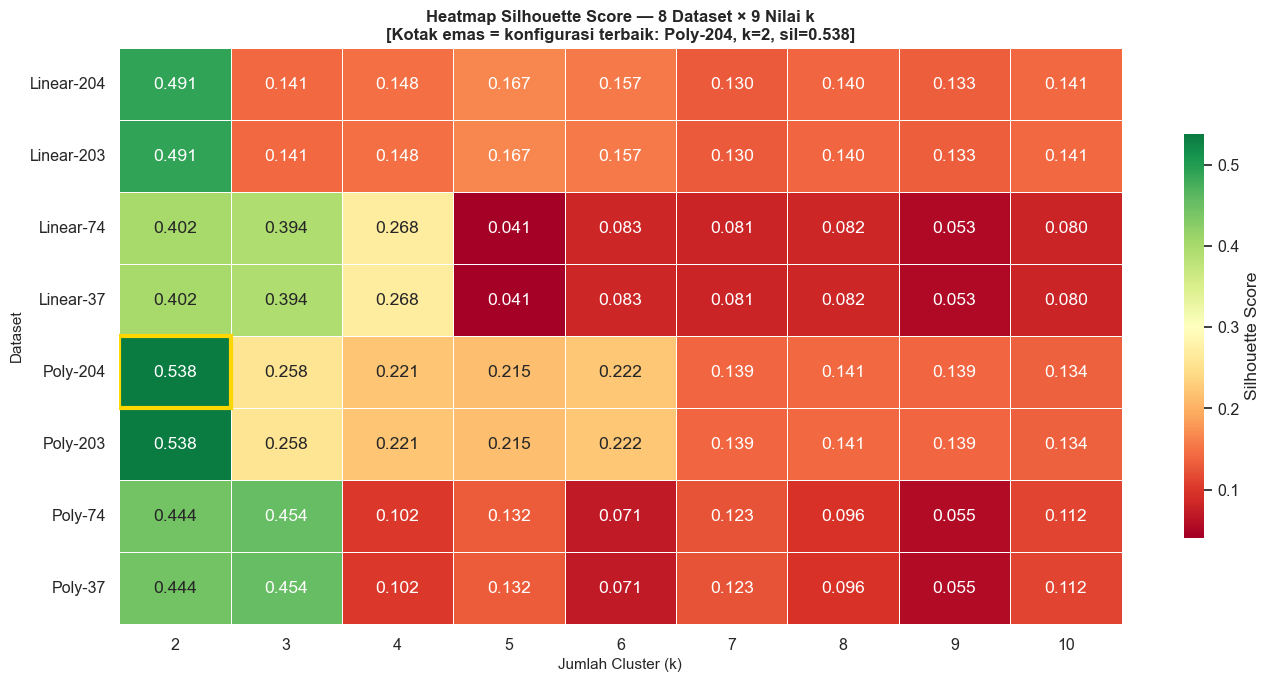

Gambar disimpan: output/07b_heatmap_silhouette.png


In [5]:
# ── Heatmap Silhouette Score ──────────────────────────────────
pivot = df_hasil.pivot(index='dataset', columns='k', values='silhouette')

# Urutkan baris sesuai urutan pipeline
urutan = ['Linear-204', 'Linear-203', 'Linear-74', 'Linear-37',
          'Poly-204',   'Poly-203',   'Poly-74',   'Poly-37']
pivot = pivot.reindex([u for u in urutan if u in pivot.index])

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    pivot, annot=True, fmt='.3f',
    cmap='RdYlGn', center=0.3,
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Silhouette Score', 'shrink': 0.7}
)

# Tandai sel terbaik
best_row_idx = list(pivot.index).index(BEST_DATASET)
best_col_idx = list(pivot.columns).index(BEST_K)
ax.add_patch(plt.Rectangle((best_col_idx, best_row_idx), 1, 1,
                             fill=False, edgecolor='gold', lw=3))

ax.set_title(f'Heatmap Silhouette Score — 8 Dataset × 9 Nilai k\n'
             f'[Kotak emas = konfigurasi terbaik: {BEST_DATASET}, k={BEST_K}, sil={BEST_SIL:.3f}]',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Jumlah Cluster (k)', fontsize=11)
ax.set_ylabel('Dataset', fontsize=11)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07b_heatmap_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: output/07b_heatmap_silhouette.png')

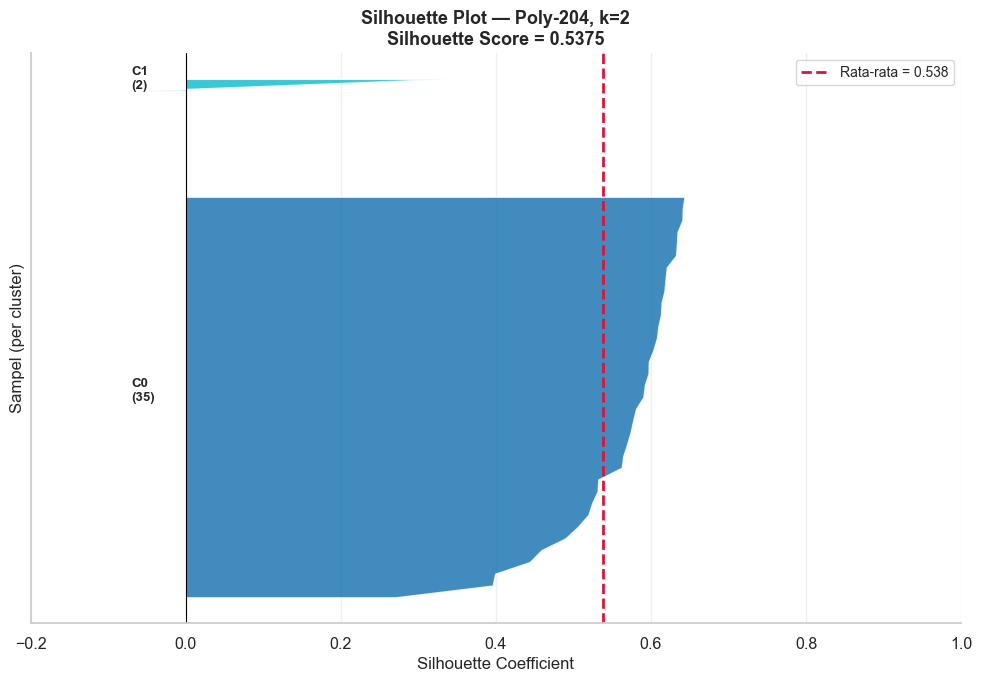

Gambar disimpan: output/08_silhouette_plot.png


In [6]:
# ── Silhouette Plot ───────────────────────────────────────────
X_best     = representasi[BEST_DATASET]
sil_vals   = silhouette_samples(X_best, BEST_LABELS)
colors_tab = plt.cm.tab10(np.linspace(0, 1, BEST_K))

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10

for i in range(BEST_K):
    vals_i  = np.sort(sil_vals[BEST_LABELS == i])
    size_i  = len(vals_i)
    y_upper = y_lower + size_i

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals_i,
                     facecolor=colors_tab[i], alpha=0.85)
    ax.text(-0.07, y_lower + size_i / 2,
            f'C{i}\n({size_i})', fontsize=9.5, va='center', fontweight='bold')
    y_lower = y_upper + 8

# Garis rata-rata
ax.axvline(x=BEST_SIL, color='crimson', linestyle='--', linewidth=2,
           label=f'Rata-rata = {BEST_SIL:.3f}')
ax.axvline(x=0, color='black', linewidth=0.8)

ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Sampel (per cluster)', fontsize=12)
ax.set_title(f'Silhouette Plot — {BEST_DATASET}, k={BEST_K}\n'
             f'Silhouette Score = {BEST_SIL:.4f}',
             fontweight='bold', fontsize=13)
ax.set_yticks([])
ax.set_xlim(-0.2, 1.0)
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: output/08_silhouette_plot.png')

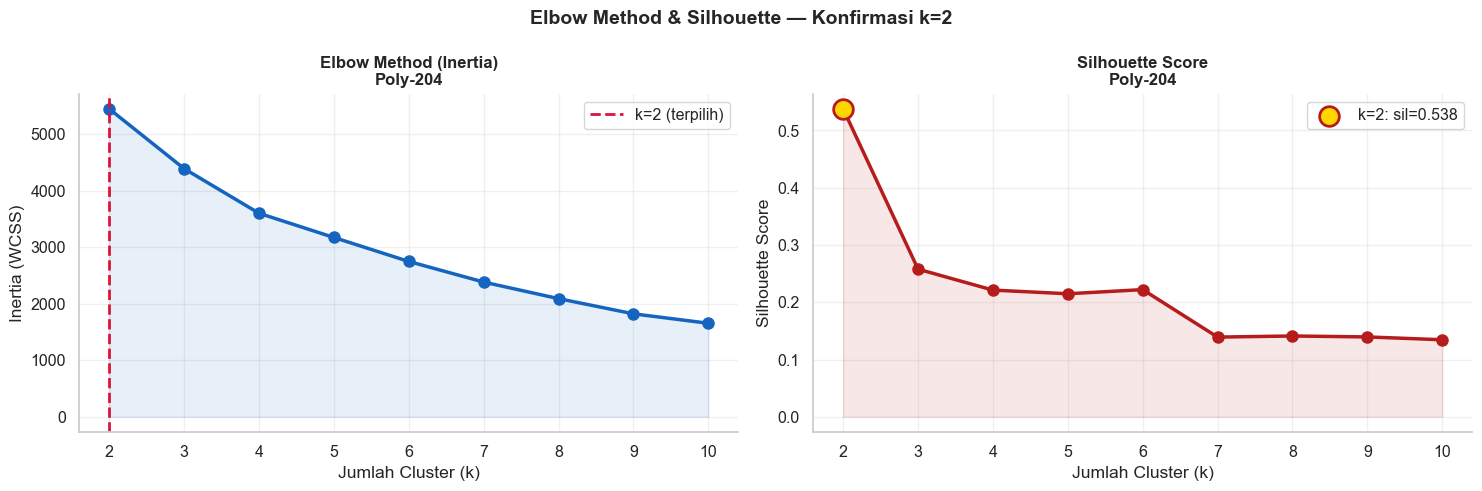

In [7]:
# ── Elbow Method ─────────────────────────────────────────────
sub_best = df_hasil[df_hasil['dataset'] == BEST_DATASET]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Elbow (Inertia)
ax = axes[0]
ax.plot(sub_best['k'], sub_best['inertia'], 'o-',
        color='#1565C0', linewidth=2.5, markersize=8)
ax.fill_between(sub_best['k'], sub_best['inertia'], alpha=0.1, color='#1565C0')
ax.axvline(BEST_K, color='crimson', linestyle='--', linewidth=2,
           label=f'k={BEST_K} (terpilih)')
ax.set_title(f'Elbow Method (Inertia)\n{BEST_DATASET}', fontweight='bold', fontsize=12)
ax.set_xlabel('Jumlah Cluster (k)')
ax.set_ylabel('Inertia (WCSS)')
ax.set_xticks(list(K_RANGE))
ax.legend()
ax.spines[['top','right']].set_visible(False)
ax.grid(True, alpha=0.3)

# Silhouette
ax = axes[1]
ax.plot(sub_best['k'], sub_best['silhouette'], 'o-',
        color='#B71C1C', linewidth=2.5, markersize=8)
ax.fill_between(sub_best['k'], sub_best['silhouette'], alpha=0.1, color='#B71C1C')
ax.scatter(BEST_K, BEST_SIL, s=200, color='gold',
           edgecolors='#B71C1C', linewidth=2, zorder=5,
           label=f'k={BEST_K}: sil={BEST_SIL:.3f}')
ax.set_title(f'Silhouette Score\n{BEST_DATASET}', fontweight='bold', fontsize=12)
ax.set_xlabel('Jumlah Cluster (k)')
ax.set_ylabel('Silhouette Score')
ax.set_xticks(list(K_RANGE))
ax.legend()
ax.spines[['top','right']].set_visible(False)
ax.grid(True, alpha=0.3)

plt.suptitle(f'Elbow Method & Silhouette — Konfirmasi k={BEST_K}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/09_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

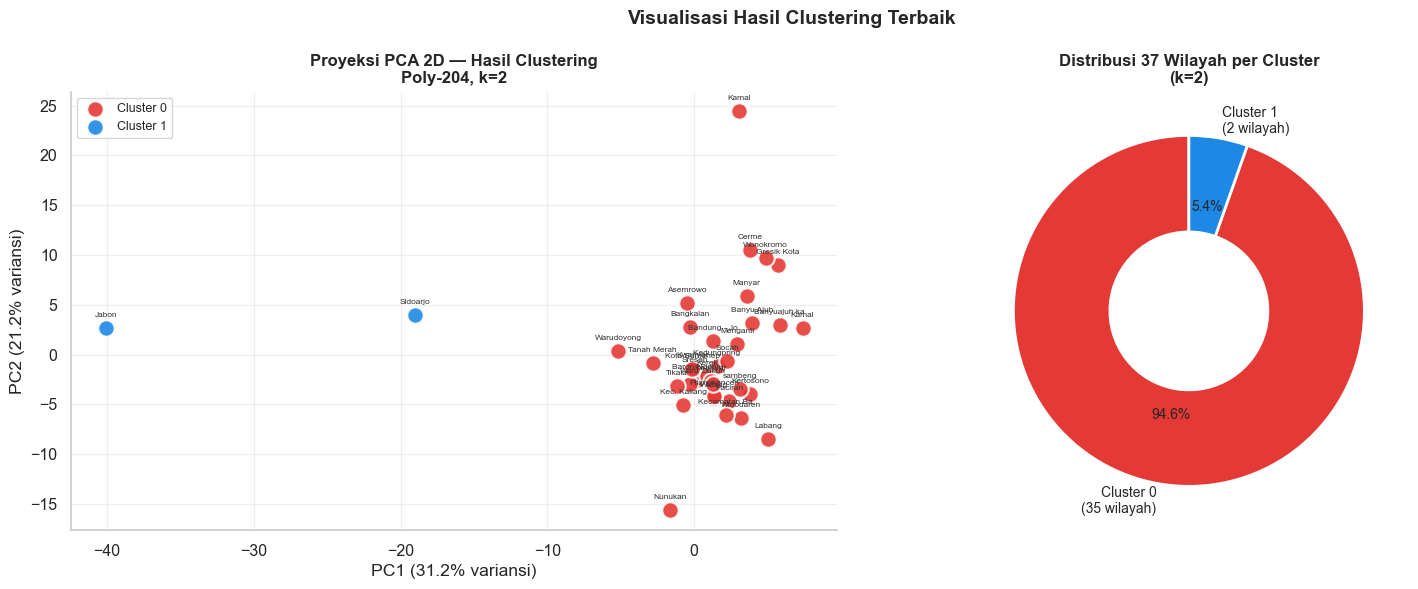

In [8]:
# ── Scatter PCA 2D + Pie Chart ───────────────────────────────
from sklearn.decomposition import PCA as PCA_viz

CLUSTER_COLORS = [
    '#E53935','#1E88E5','#43A047','#FB8C00','#8E24AA',
    '#00ACC1','#F06292','#FDD835','#6D4C41','#78909C'
]

pca2d  = PCA_viz(n_components=2, random_state=42)
X_viz  = pca2d.fit_transform(X_best)

meta_best = meta_linear if 'Linear' in BEST_DATASET else meta_poly

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter
ax = axes[0]
for c in range(BEST_K):
    mask = BEST_LABELS == c
    ax.scatter(X_viz[mask, 0], X_viz[mask, 1], s=140,
               color=CLUSTER_COLORS[c], edgecolors='white',
               linewidth=1.5, label=f'Cluster {c}', alpha=0.9, zorder=3)
    for idx in np.where(mask)[0]:
        label_txt = meta_best.iloc[idx]['daerah'].split(',')[0][:12]
        ax.annotate(label_txt,
                    xy=(X_viz[idx,0], X_viz[idx,1]),
                    xytext=(0, 8), textcoords='offset points',
                    fontsize=6, ha='center', color='#333')

ax.set_title(f'Proyeksi PCA 2D — Hasil Clustering\n{BEST_DATASET}, k={BEST_K}',
             fontweight='bold', fontsize=12)
ax.set_xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]:.1%} variansi)')
ax.set_ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]:.1%} variansi)')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.grid(True, alpha=0.3)

# Pie
ax2 = axes[1]
uniq, cnts = np.unique(BEST_LABELS, return_counts=True)
ax2.pie(cnts,
        labels=[f'Cluster {u}\n({c} wilayah)' for u,c in zip(uniq,cnts)],
        colors=[CLUSTER_COLORS[u] for u in uniq],
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
        textprops={'fontsize': 10})
ax2.set_title(f'Distribusi 37 Wilayah per Cluster\n(k={BEST_K})',
              fontweight='bold', fontsize=12)

plt.suptitle('Visualisasi Hasil Clustering Terbaik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/10_scatter_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

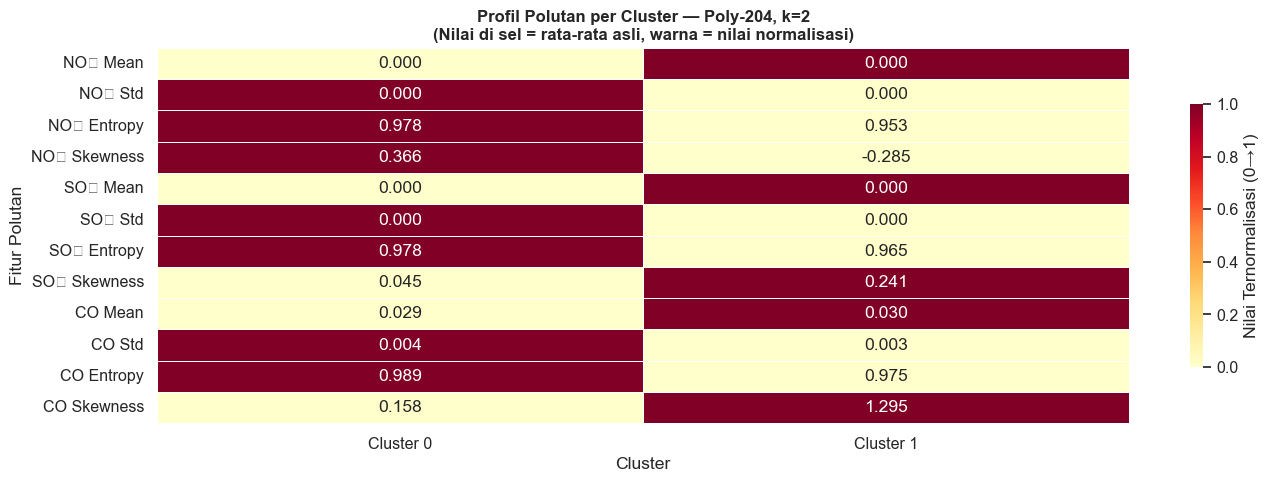

Gambar disimpan: output/11_profil_cluster.png


In [9]:
# ── Profil rata-rata fitur kunci per cluster ──────────────────
X_raw = X_linear if 'Linear' in BEST_DATASET else X_poly
key_cols, key_labels = [], []
for pol, pol_lbl in [('no2','NO₂'), ('so2','SO₂'), ('co','CO')]:
    for feat, feat_lbl in [('calc_mean','Mean'), ('calc_std','Std'),
                            ('entropy','Entropy'), ('skewness','Skewness')]:
        col = f'{pol}_{feat}'
        if col in X_raw.columns:
            key_cols.append(col)
            key_labels.append(f'{pol_lbl} {feat_lbl}')

df_profil = X_raw[key_cols].copy()
df_profil['cluster'] = BEST_LABELS
profil = df_profil.groupby('cluster')[key_cols].mean()

# Normalisasi 0-1 per fitur (agar warna dapat dibandingkan)
profil_norm = (profil - profil.min()) / (profil.max() - profil.min() + 1e-10)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    profil_norm.T,
    annot=profil.T.round(3),   # Tampilkan nilai asli, bukan normalisasi
    fmt='.3f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    xticklabels=[f'Cluster {c}' for c in profil.index],
    yticklabels=key_labels,
    cbar_kws={'label': 'Nilai Ternormalisasi (0→1)', 'shrink': 0.7}
)
ax.set_title(f'Profil Polutan per Cluster — {BEST_DATASET}, k={BEST_K}\n'
             f'(Nilai di sel = rata-rata asli, warna = nilai normalisasi)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Cluster')
ax.set_ylabel('Fitur Polutan')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/11_profil_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: output/11_profil_cluster.png')

In [10]:
# ── Simpan hasil untuk Tahap 4 ────────────────────────────────
save_data = {
    'BEST_DATASET' : BEST_DATASET,
    'BEST_K'       : BEST_K,
    'BEST_SIL'     : BEST_SIL,
    'BEST_LABELS'  : BEST_LABELS,
    'CLUSTER_COLORS': CLUSTER_COLORS,
    'meta_linear'  : meta_linear,
    'meta_poly'    : meta_poly,
    'X_linear'     : X_linear,
    'X_poly'       : X_poly,
    'df_hasil'     : df_hasil,
    'ringkasan'    : ringkasan,
}
save_path = f'{OUTPUT_DIR}/tahap3_clustering.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(save_data, f)

print(f'Hasil clustering disimpan: {os.path.abspath(save_path)}')
print(f'Ukuran file               : {os.path.getsize(save_path)/1024:.1f} KB')
print('\nDistribusi wilayah per cluster:')
meta_best2 = meta_linear if 'Linear' in BEST_DATASET else meta_poly
for c in range(BEST_K):
    wil = meta_best2[BEST_LABELS == c]['daerah'].tolist()
    print(f'  Cluster {c} ({len(wil)} wilayah): {", ".join(wil)}')
print('\n→ Lanjut ke Tahap 4: Visualisasi Peta Segmentasi')

Hasil clustering disimpan: C:\Users\OKAN\OneDrive\Dokumen\PSD\materi\Clustering_Segmentasi\output\tahap3_clustering.pkl
Ukuran file               : 134.4 KB

Distribusi wilayah per cluster:
  Cluster 0 (35 wilayah): Baron Nganjuk, Nunukan, Sreseh, Sampang, Manyar, Gresik, Kamal, Bangkalan, Kedungpring Lamongan, Gresik Kota, Gresik, Waru, Pamekasan, Paciran, Lamongan, Kertosono, Nganjuk, Menganti, Gresik, Bandung - Jogoroto, Jombang, Banyu Ajuh, Perumnas, Kamal, Widang, Tuban, Kwanyar, Bangkalan, sambeng, lamongan, Kec. Kalianget, Sumenep, Cerme, Gresik, Tikala, Manado, Kerek, Tuban, Kwanyar, Bangkalan, Wonokromo, Surabaya, Asemrowo, Surabaya, Kota Sumenep, Sumenep, Socah, Bangkalan, Pilangkenceng, Madiun, Tanah Merah, Bangkalan, Labang, Bangkalan, Widodaren, Ngawi, Bangkalan, Bangkalan, Warudoyong, Kota Sukabumi, Kamal, Bangkalan, Banyuajuh kamal, Bangkalan, Dukun, Gresik, Kecamatan Bangkalan,Bangkalan
  Cluster 1 (2 wilayah): Jabon, Sidoarjo, Sidoarjo, Wonoayu

→ Lanjut ke Tahap 4: Vi